In [1]:
import seaborn as sns 
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("result/task1_comparison.csv")
diff = pd.read_csv("result/task1_comparison_diff.csv")
df8 = pd.read_csv("result/task1_analysis_sub8.csv")
df.columns

Index(['company', 'Model', 'name', 'model', 'f1_score', 'MOE', 'Reasoning',
       'size', 'Unnamed: 8'],
      dtype='object')

/opt/homebrew/Caskroom/miniforge/base/envs/agents/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


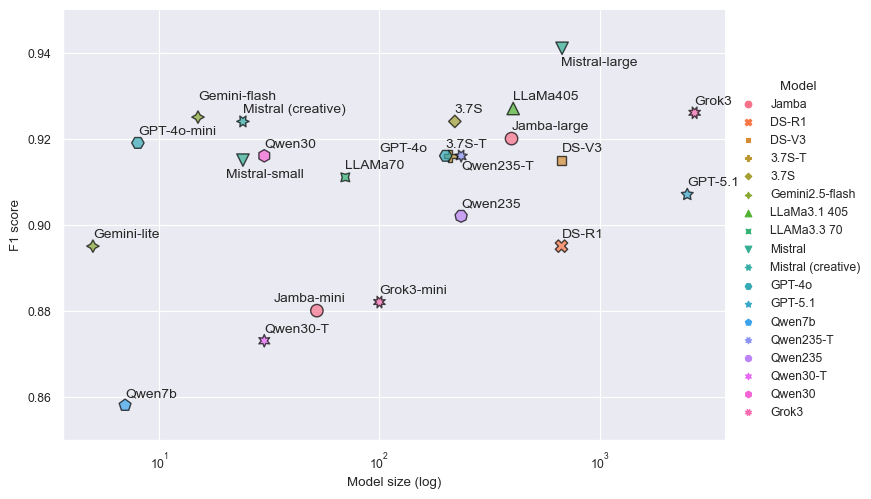

In [2]:
sns.set_theme(context="paper", style="darkgrid")
g = sns.relplot(
    data=df,
    x="size",
    y="f1_score",
    hue="Model",
    #size="difficulty",
    #sizes=(50, 200),
    s = 80, 
    alpha=0.7,
    style="Model",
    height=5,
    aspect=1.5,
    edgecolor="black",
    linewidth=1,
)
plt.xscale('log')
plt.xlabel("Model size (log)")
plt.ylabel("F1 score")
for i, row in df.iterrows():
    _y = 0.002
    _x = 0
    if row['Model'] == "Mistral":
        _y = -0.004
        _x = -4
    if row['Model'] == "Qwen235-T":
        _y = -0.003
        _x = 0
    if row['name'] == "GPT-4o":
        _y = 0.001
        _x = -100
    if row['Model'] == "3.7S-T":
        _y = .0019
        _x = -10
    if row['name'] == "Jamba-mini":
        _y = .002
        _x = -19
    if row['name'] == "Gemini-flash":
        _y = .004
    g.ax.text(row['size'] + _x, row['f1_score'] + _y, 
             row['name'], 
             fontsize=10)
  # adjust layout
plt.ylim([0.85, 0.95])
plt.savefig("task1_plot/task1_size.pdf", bbox_inches="tight") 

In [3]:
from scipy.stats import spearmanr 
rho, p = spearmanr(df["f1_score"], df["size"])
print("f1 and size!" + f" Spearman ρ = {rho:.3f}, p-value = {p:.4f}")

f1 and size! Spearman ρ = 0.311, p-value = 0.1485


/opt/homebrew/Caskroom/miniforge/base/envs/agents/lib/python3.9/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


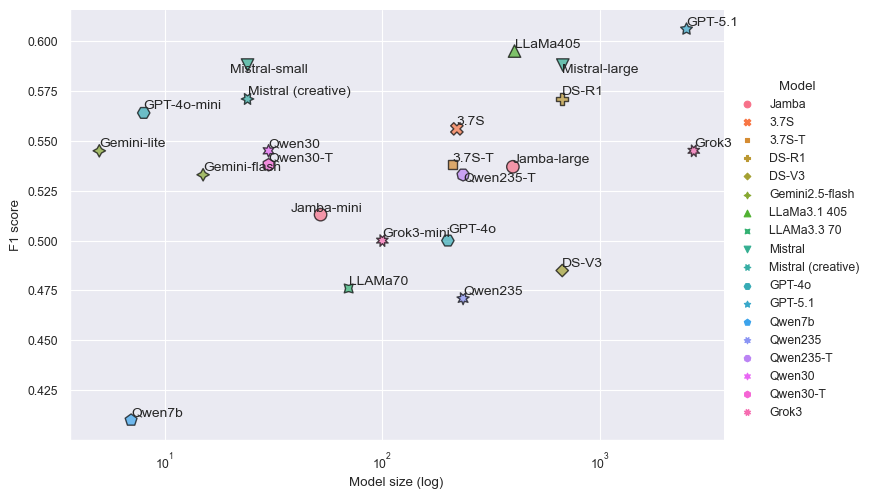

In [4]:
level = "High"
tg = diff[diff.difficulty_level == level].reset_index()
sns.set_theme(context="paper", style="darkgrid")
g = sns.relplot(
    data=tg,
    x="size",
    y="f1_score",
    hue="Model",
    s = 80, 
    #size="difficulty",
    #sizes=(50, 200),
    alpha=0.7,
    style="Model",
    height=5,
    aspect=1.5,
    edgecolor="black",
    linewidth=1,
)
plt.xscale('log')
plt.xlabel("Model size (log)")
plt.ylabel("F1 score")
for i, row in tg.iterrows():
    _y = 0.002
    _x = 0
    if row['Model'] == "Mistral":
        _y = -0.004
        _x = -4
    if row['Model'] == "Qwen235-T":
        _y = -0.003
        _x = 0
    if row['name'] == "GPT-4o":
        _y = 0.004
        _x = 0
    if row['Model'] == "3.7S-T":
        _y = .0015
        _x = 0
    if row['name'] == "Jamba-mini":
        _y = .0015
        _x = -14
    g.ax.text(row['size'] + _x, row['f1_score'] + _y, 
             row['name'], 
             fontsize=10)

plt.savefig("task1_plot/" + level + "_task1_size.pdf", bbox_inches="tight") 